In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Task 1
# Data Preparation

### Loading Data

In [2]:
df_input = pd.read_csv("dry room 1_input.csv")
df_output = pd.read_csv("dry room 1_output.csv")
df_carbon = pd.read_excel("DE_2023_hourly.xls")
df_market = pd.read_csv("Electricity_production_and_spot_prices_in_Germany_in_2023.csv")

In [3]:
df_input.head()

,time,numOfHum,outsideTemp,relHumidity,heatload,DPT_room_lim,DPT_in
0,2023-01-01 00:00:00,2,2.088032,89.558556,0.0,-45,-60
1,2023-01-01 01:00:00,1,1.591280,90.448114,0.0,-45,-60
2,2023-01-01 02:00:00,2,1.312749,90.889011,0.0,-45,-60
3,2023-01-01 03:00:00,2,1.831118,91.313950,0.0,-45,-60
4,2023-01-01 04:00:00,0,1.087071,93.195124,0.0,-45,-60


## Checking missing values in `dry room 1_input.csv`

In [4]:
df_input.isna().sum()

time            0
numOfHum        0
outsideTemp     0
relHumidity     0
heatload        0
DPT_room_lim    0
DPT_in          0
dtype: int64

In [5]:
df_input.dtypes

time             object
numOfHum          int64
outsideTemp     float64
relHumidity     float64
heatload        float64
DPT_room_lim      int64
DPT_in            int64
dtype: object

## Renaming the column containing date time to `timestamp` across all datasets for consistency and convert it into `datetime` format

In [6]:
df_input.rename(columns={'time': 'timestamp'}, inplace=True)
df_input['timestamp'] = pd.to_datetime(df_input['timestamp'])
df_input['timestamp'] = df_input['timestamp'].dt.tz_localize('Europe/Berlin', ambiguous='NaT', nonexistent='NaT').dt.tz_convert('UTC')
df_input.dtypes

timestamp       datetime64[ns, UTC]
numOfHum                      int64
outsideTemp                 float64
relHumidity                 float64
heatload                    float64
DPT_room_lim                  int64
DPT_in                        int64
dtype: object

In [7]:
print(df_input['timestamp'].isna().sum())

2


In [8]:
# Dropping ambiguous timestamps during DST transitions (2 rows)
df_input = df_input.dropna(subset=['timestamp'])

In [9]:
print(df_input['timestamp'].isna().sum())

0


In [10]:
df_output.head()

,timestamp,PV,VK1,VK2,ZL,RE,ZL_neu,RV,electricity_W,heat_W
0,2023-01-01 00:00:00,2.625479,0.0,7.182365,6.298567,50.602754,3.443660,3.76,13567.843896,60344.980965
1,2023-01-01 01:00:00,2.105473,0.0,6.580392,4.921305,50.424572,2.399837,3.76,12445.864914,57745.713892
2,2023-01-01 02:00:00,2.404857,0.0,6.873119,5.917089,50.820109,2.986471,3.76,13037.975897,59723.669262
3,2023-01-01 03:00:00,2.632285,0.0,7.159727,6.398357,50.319284,3.456958,3.76,13552.011467,60174.599115
4,2023-01-01 04:00:00,1.741136,0.0,6.086613,3.774173,50.339799,1.751859,3.76,11587.749303,55865.829678


## Checking missing values in `dry room 1_output.csv`

In [11]:
df_output.isna().sum()

timestamp        0
PV               0
VK1              0
VK2              0
ZL               0
RE               0
ZL_neu           0
RV               0
electricity_W    0
heat_W           0
dtype: int64

In [12]:
df_output.dtypes

timestamp         object
PV               float64
VK1              float64
VK2              float64
ZL               float64
RE               float64
ZL_neu           float64
RV               float64
electricity_W    float64
heat_W           float64
dtype: object

In [13]:
df_output['timestamp'] = pd.to_datetime(df_output['timestamp'])
df_output['timestamp'] = df_output['timestamp'].dt.tz_localize('Europe/Berlin', ambiguous='NaT', nonexistent='NaT').dt.tz_convert('UTC')
df_output.dtypes

timestamp        datetime64[ns, UTC]
PV                           float64
VK1                          float64
VK2                          float64
ZL                           float64
RE                           float64
ZL_neu                       float64
RV                           float64
electricity_W                float64
heat_W                       float64
dtype: object

In [14]:
print(df_output['timestamp'].isna().sum())

2


In [15]:
# Dropping ambiguous timestamps during DST transitions (2 rows)
df_output = df_output.dropna(subset=['timestamp'])

In [16]:
print(df_output['timestamp'].isna().sum())

0


In [17]:
df_carbon.head()

,Datetime (UTC),Country,Zone Name,Zone Id,Carbon Intensity gCOâ‚‚eq/kWh (direct),Carbon Intensity gCOâ‚‚eq/kWh (LCA),Low Carbon Percentage,Renewable Percentage,Data Source,Data Estimated,Data Estimation Method
0,2023-01-01 00:00:00,Germany,Germany,DE,140.51,185.80,83.79,78.42,entsoe.eu,False,NaN
1,2023-01-01 01:00:00,Germany,Germany,DE,140.44,185.70,83.85,78.93,entsoe.eu,False,NaN
2,2023-01-01 02:00:00,Germany,Germany,DE,148.34,195.42,82.95,77.74,entsoe.eu,False,NaN
3,2023-01-01 03:00:00,Germany,Germany,DE,149.55,197.06,82.78,77.51,entsoe.eu,False,NaN
4,2023-01-01 04:00:00,Germany,Germany,DE,148.04,195.41,83.00,77.74,entsoe.eu,False,NaN


## Checking missing values in `DE_2023_hourly.xls`

In [18]:
print(df_carbon.isna().sum())

Datetime (UTC)                               0
Country                                      0
Zone Name                                    0
Zone Id                                      0
Carbon Intensity gCOâ‚‚eq/kWh (direct)       0
Carbon Intensity gCOâ‚‚eq/kWh (LCA)          0
Low Carbon Percentage                        0
Renewable Percentage                         0
Data Source                                  0
Data Estimated                               1
Data Estimation Method                    8731
dtype: int64


## The `Data Estimation Method` has too many missing entries. Lets see how much is its proportion.

In [19]:
print(df_carbon.isna().mean() * 100)

Datetime (UTC)                             0.000000
Country                                    0.000000
Zone Name                                  0.000000
Zone Id                                    0.000000
Carbon Intensity gCOâ‚‚eq/kWh (direct)     0.000000
Carbon Intensity gCOâ‚‚eq/kWh (LCA)        0.000000
Low Carbon Percentage                      0.000000
Renewable Percentage                       0.000000
Data Source                                0.000000
Data Estimated                             0.011416
Data Estimation Method                    99.668950
dtype: float64


## It would be better if we drop the column `Data Estimation Method`

In [20]:
df_carbon.drop(columns=['Data Estimation Method'], inplace=True)

## Also dropping the missing entries of `Data Estimated` but this time removing the emtpy rows not column as we did for `Data Estimation Method`

In [21]:
df_carbon = df_carbon.dropna(axis=0)

In [22]:
df_carbon.isna().sum()

Datetime (UTC)                            0
Country                                   0
Zone Name                                 0
Zone Id                                   0
Carbon Intensity gCOâ‚‚eq/kWh (direct)    0
Carbon Intensity gCOâ‚‚eq/kWh (LCA)       0
Low Carbon Percentage                     0
Renewable Percentage                      0
Data Source                               0
Data Estimated                            0
dtype: int64

In [23]:
df_carbon.dtypes

Datetime (UTC)                            datetime64[ns]
Country                                           object
Zone Name                                         object
Zone Id                                           object
Carbon Intensity gCOâ‚‚eq/kWh (direct)           float64
Carbon Intensity gCOâ‚‚eq/kWh (LCA)              float64
Low Carbon Percentage                            float64
Renewable Percentage                             float64
Data Source                                       object
Data Estimated                                    object
dtype: object

In [24]:
df_carbon['Datetime (UTC)'] = df_carbon['Datetime (UTC)'].dt.tz_localize('UTC')
df_carbon.rename(columns={'Datetime (UTC)': 'timestamp'}, inplace=True)

In [25]:
df_carbon.columns.to_list()

['timestamp',
 'Country',
 'Zone Name',
 'Zone Id',
 'Carbon Intensity gCOâ‚‚eq/kWh (direct)',
 'Carbon Intensity gCOâ‚‚eq/kWh (LCA)',
 'Low Carbon Percentage',
 'Renewable Percentage',
 'Data Source',
 'Data Estimated']

In [26]:
df_market.head()

,Date (GMT+1),Nuclear,Non-Renewable,Renewable,Day Ahead Auction (DE-LU)
0,NaN,Power (MW),Power (MW),Power (MW),"Price (EUR/MWh, EUR/tCO2)"
1,2023-01-01T00:00+01:00,2459.17,9265.614572,36641.97777,-5.17
2,2023-01-01T01:00+01:00,2458.6025,9042.471891,37696.83394,-1.07
3,2023-01-01T02:00+01:00,2459.645,8955.260549,37849.30209,-1.47
4,2023-01-01T03:00+01:00,2460.475,8967.997791,35565.44802,-5.08


## Here the header is distributed to the second row and the first entry of date is empty. Lets fix this.

In [27]:
df_market = pd.read_csv('Electricity_production_and_spot_prices_in_Germany_in_2023.csv', header=[0,1])
df_market.columns = [' '.join(col).strip() for col in df_market.columns]
df_market.head()

,Date (GMT+1) Unnamed: 0_level_1,Nuclear Power (MW),Non-Renewable Power (MW),Renewable Power (MW),"Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)"
0,2023-01-01T00:00+01:00,2459.1700,9265.614572,36641.97777,-5.17
1,2023-01-01T01:00+01:00,2458.6025,9042.471891,37696.83394,-1.07
2,2023-01-01T02:00+01:00,2459.6450,8955.260549,37849.30209,-1.47
3,2023-01-01T03:00+01:00,2460.4750,8967.997791,35565.44802,-5.08
4,2023-01-01T04:00+01:00,2460.8025,8971.925269,35084.99508,-4.49


## We got Unnamed:0_level_1 along with our `Date (GMT + 1)`, so simply renaming it.

In [28]:
df_market.rename(columns={'Date (GMT+1) Unnamed: 0_level_1': 'timestamp'}, inplace=True)

In [29]:
df_market.columns.to_list()

['timestamp',
 'Nuclear Power (MW)',
 'Non-Renewable Power (MW)',
 'Renewable Power (MW)',
 'Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)']

In [30]:
df_market.isna().sum()

timestamp                                                 0
Nuclear Power (MW)                                     6241
Non-Renewable Power (MW)                                  0
Renewable Power (MW)                                      0
Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)       0
dtype: int64

In [31]:
df_market.isna().mean() * 100

timestamp                                               0.000000
Nuclear Power (MW)                                     71.244292
Non-Renewable Power (MW)                                0.000000
Renewable Power (MW)                                    0.000000
Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)     0.000000
dtype: float64

## Even though the column Nuclear Power has 71 percent of its entry empty, we cannot simply drop it, so we are filling it with 0.

In [32]:
df_market['Nuclear Power (MW)'] = df_market['Nuclear Power (MW)'].fillna(0)


In [33]:
print(df_market['Nuclear Power (MW)'].isna().sum())

0


In [34]:
df_market.dtypes

timestamp                                               object
Nuclear Power (MW)                                     float64
Non-Renewable Power (MW)                               float64
Renewable Power (MW)                                   float64
Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)    float64
dtype: object

## This timestamp has mixed timezone offsets (some +01:00, some +02:00 due to DST). So, we are using utc=True directly.

In [35]:
df_market['timestamp'] = pd.to_datetime(df_market['timestamp'], utc=True)

## Checking if all the timestamp has been converted to UTC

In [36]:
for name, df in {'df_input': df_input, 'df_output': df_output, 'df_carbon': df_carbon, 'df_market': df_market}.items():
    print(f"{name}: {df['timestamp'].dtype}")

df_input: datetime64[ns, UTC]
df_output: datetime64[ns, UTC]
df_carbon: datetime64[ns, UTC]
df_market: datetime64[ns, UTC]


## Let see the range of timestamp to have overview of the start and end of the datetime recorded

In [37]:
for name, df in {'df_input': df_input, 'df_output': df_output, 'df_carbon': df_carbon, 'df_market': df_market}.items():
    print(f"\n--- {name} ---")
    print(f"Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print(f"Rows: {len(df)}")


--- df_input ---
Range: 2022-12-31 23:00:00+00:00 to 2023-12-31 23:00:00+00:00
Rows: 8759

--- df_output ---
Range: 2022-12-31 23:00:00+00:00 to 2023-12-31 23:00:00+00:00
Rows: 8759

--- df_carbon ---
Range: 2023-01-01 00:00:00+00:00 to 2023-12-31 23:00:00+00:00
Rows: 8759

--- df_market ---
Range: 2022-12-31 23:00:00+00:00 to 2023-12-31 22:00:00+00:00
Rows: 8760


## Interpretation
**df_input** and **df_output** have same date range and  same number of rows 
**df_carbon** starts 1 hour later, missing the first hour.
**df_market** ends 1 hour earlier and this time it has missing entry of last hour, but has **8760** rows.
Lets check if it has duplicate entries.

In [38]:
print(df_market['timestamp'].duplicated().sum())

0


In [39]:
print(df_market[df_market['timestamp'].duplicated(keep=False)])

Empty DataFrame
Columns: [timestamp, Nuclear Power (MW), Non-Renewable Power (MW), Renewable Power (MW), Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)]
Index: []


## Applying inner join so it will select only those timestamp present in all four datasets

In [40]:
df_merged = df_input.merge(df_output, on='timestamp', how='inner') \
                    .merge(df_carbon, on='timestamp', how='inner') \
                    .merge(df_market, on='timestamp', how='inner')

print(len(df_merged))

8756


In [41]:
print(df_merged.shape)

(8756, 29)


# Task 2
# Modelling

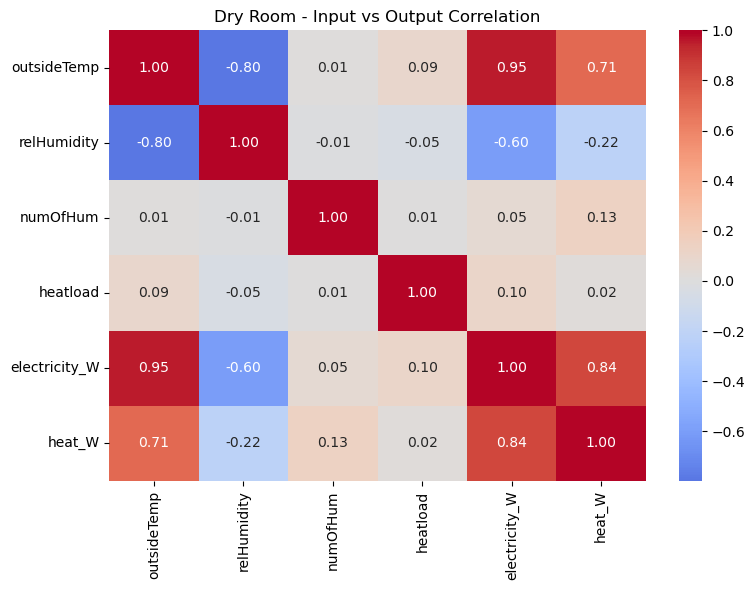

In [42]:
# 1. Dry room: input vs output
dry_room_cols = ['outsideTemp', 'relHumidity', 'numOfHum', 'heatload', 'electricity_W', 'heat_W']
corr1 = df_merged[dry_room_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr1, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Dry Room - Input vs Output Correlation')
plt.tight_layout()
plt.show()


In [43]:
# Main drivers table
output_cols = ['electricity_W', 'heat_W']
corr_focused = df_merged[dry_room_cols].corr()[output_cols].drop(output_cols)
corr_focused.style.background_gradient(cmap='coolwarm') \
              .set_caption("Dry Room Energy Drivers Correlation") \
              .format("{:.2f}")

,electricity_W,heat_W
outsideTemp,0.95,0.71
relHumidity,-0.60,-0.22
numOfHum,0.05,0.13
heatload,0.10,0.02


## Interpretation
**Dry Room Energy Drivers**  

`outsideTemp` is by far the dominant driver with 0.95 correlation to electricity and 0.71 to heat. External temperature almost entirely determines how hard the dry room has to work. `relHumidity` has a moderate negative effect (-0.60) on electricity, higher ambient humidity means less electrical energy needed for dehumidification. Internal factors `numOfHum (personnel)` and `heatload (machinery)` show near-zero correlation, meaning they have negligible influence on energy demand despite being assumed contributors.  

**Conclusion:**  
External factors dominate over internal factors, which contradicts the common assumption that personnel and machinery significantly drive dry room energy consumption.

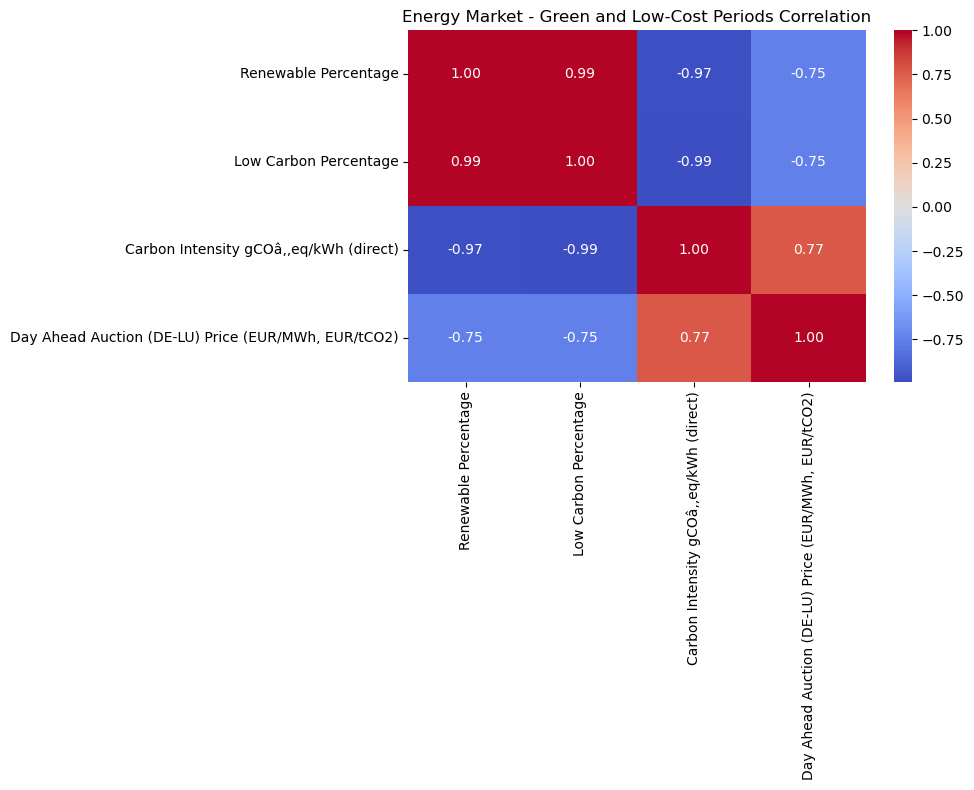

In [44]:
# 2. Green and low-cost periods
market_cols = ['Renewable Percentage', 'Low Carbon Percentage', 
               'Carbon Intensity gCOâ‚‚eq/kWh (direct)', 
               'Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)']
corr2 = df_merged[market_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Energy Market - Green and Low-Cost Periods Correlation')
plt.tight_layout()
plt.show()

In [45]:
# Main drivers table
price_col = ['Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)']
green_cols = ['Renewable Percentage', 'Low Carbon Percentage', 
              'Carbon Intensity gCOâ‚‚eq/kWh (direct)']

corr_market = df_merged[market_cols].corr()[price_col].drop(price_col)
corr_market.style.background_gradient(cmap='coolwarm') \
               .set_caption("Market Drivers: Green vs Price Correlation") \
               .format("{:.2f}")


,"Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)"
Renewable Percentage,-0.75
Low Carbon Percentage,-0.75
Carbon Intensity gCOâ‚‚eq/kWh (direct),0.77


## Interpretation
`Renewable Percentage` and Low `Carbon Percentage` both show strong negative correlation (-0.75) with price,  it means when renewable enery percentage are high, prices drop significantly. `Carbon Intensity` shows strong positive correlation (+0.77) which signifies fossil-heavy hours are expensive hours.

**Conclusion:**  
 Green periods and low-cost periods strongly coincide in Germany's 2023 grid. Scheduling dry room operation during high renewable / low carbon intensity hours is simultaneously the most economical and environmentally optimal strategy — you don't have to trade one off against the other.


# Task 3
# Developing Predictive Model

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and targets
X = df_merged[['outsideTemp', 'relHumidity', 'numOfHum', 'heatload']]
y = df_merged[['electricity_W', 'heat_W']]

# Step 1: split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: split train and validation (20% of remaining)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 5603, Val: 1401, Test: 1752


In [47]:
# Hyperparameters to try
param_grid = {
    'estimator__n_estimators': [50, 100, 200],
    'estimator__max_depth': [5, 10, 20, None],
    'estimator__min_samples_split': [2, 5, 10]
}

model = MultiOutputRegressor(RandomForestRegressor(random_state=42))

# 5-fold cross validation on training data only
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R² score:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'estimator__max_depth': None, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}
Best CV R² score: 0.9973426348392035


## Cross-Validation Results

The best model achieved an R² score of 0.997 on cross-validation, which is unusually high. 
Two possible explanations are considered:

1. **Overfitting**: The optimal parameters include `max_depth=None`, meaning trees grow 
without any depth limit, which can lead to memorization of training data rather than 
learning generalizable patterns.

2. **Genuine strong pattern**: The correlation analysis already revealed that `outsideTemp` 
alone has a 0.95 correlation with `electricity_W`, suggesting the input-output relationship 
is inherently very strong in this dataset.

To distinguish between these two cases, the model is evaluated on the held-out validation 
set in the next step.

# Evaluation on  train set and validation set to check for overfitting

In [48]:
best_model = grid_search.best_estimator_

# Train error
y_train_pred = best_model.predict(X_train)
# Validation error
y_val_pred = best_model.predict(X_val)

for i, col in enumerate(['electricity_W', 'heat_W']):
    print(f"\n--- {col} ---")
    print(f"Train R²: {r2_score(y_train.iloc[:, i], y_train_pred[:, i]):.4f}")
    print(f"Val R²:   {r2_score(y_val.iloc[:, i], y_val_pred[:, i]):.4f}")


--- electricity_W ---
Train R²: 0.9999
Val R²:   0.9993

--- heat_W ---
Train R²: 0.9995
Val R²:   0.9959


The gap between training and validation R² is minimal for both outputs, **0.0006** for 
`electricity_W` and **0.0036** for `heat_W`. This suggests the model is **not overfitting** 
despite the unlimited tree depth (`max_depth=None`).

The consistently high R² on the validation set confirms that the strong performance 
observed during cross-validation reflects **genuine patterns in the data** rather than 
memorization. The dominant influence of `outsideTemp` identified in the correlation 
analysis provides a physical explanation for why the model generalizes so well.

# Visually inspecting using learning curve

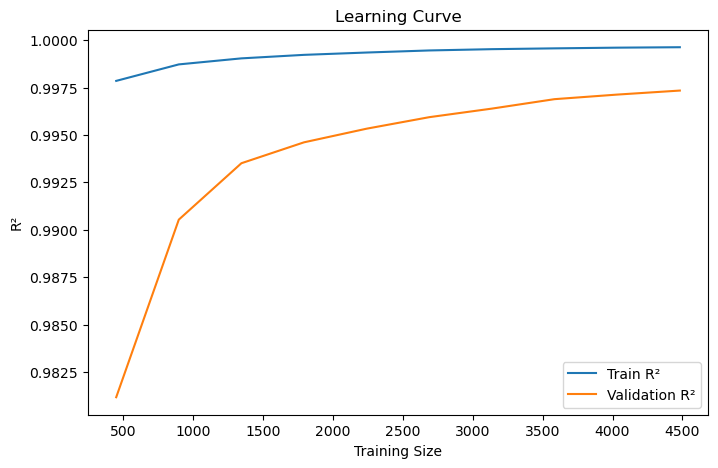

In [49]:

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, 
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train R²')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation R²')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.title('Learning Curve')
plt.legend()
plt.show()

# Testing the model

In [50]:
y_test_pred = best_model.predict(X_test)

for i, col in enumerate(['electricity_W', 'heat_W']):
    print(f"\n--- {col} ---")
    print(f"Train R²: {r2_score(y_train.iloc[:, i], y_train_pred[:, i]):.4f}")
    print(f"Val R²:   {r2_score(y_val.iloc[:, i], y_val_pred[:, i]):.4f}")
    print(f"Test R²:  {r2_score(y_test.iloc[:, i], y_test_pred[:, i]):.4f}")
    print(f"MAE:      {mean_absolute_error(y_test.iloc[:, i], y_test_pred[:, i]):.2f} W")
    print(f"RMSE:     {np.sqrt(mean_squared_error(y_test.iloc[:, i], y_test_pred[:, i])):.2f} W")


--- electricity_W ---
Train R²: 0.9999
Val R²:   0.9993
Test R²:  0.9994
MAE:      127.70 W
RMSE:     273.06 W

--- heat_W ---
Train R²: 0.9995
Val R²:   0.9959
Test R²:  0.9965
MAE:      298.10 W
RMSE:     479.27 W


The model generalizes well across all three sets with consistent R² scores, 
confirming no overfitting. Key observations:

- **electricity_W** performs slightly better than **heat_W** across all metrics,
which aligns with the stronger correlation (0.95 vs 0.71) found during EDA.

- The small and consistent gap between Train, Validation and Test R² across 
both outputs confirms the model has learned genuine patterns rather than 
memorizing training data.

- **heat_W** has higher MAE and RMSE, suggesting heat demand is slightly harder 
to predict — likely because it is influenced by more complex thermal dynamics 
compared to electricity demand.

Overall the Random Forest multi-output model demonstrates strong predictive 
performance for both electricity and heat demand estimation.

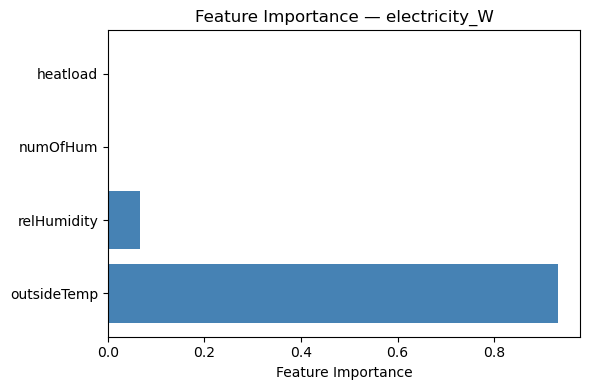

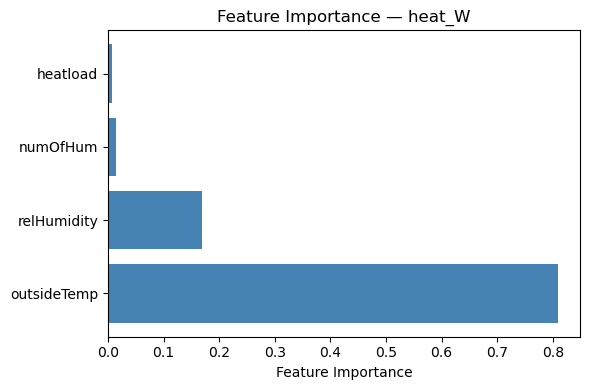

In [51]:
# Extract feature importances for each output
feature_names = ['outsideTemp', 'relHumidity', 'numOfHum', 'heatload']

for i, col in enumerate(['electricity_W', 'heat_W']):
    importances = best_model.estimators_[i].feature_importances_
    plt.figure(figsize=(6, 4))
    plt.barh(feature_names, importances, color='steelblue')
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance — {col}')
    plt.tight_layout()
    plt.show()

In [52]:
from xgboost import XGBRegressor

# XGBoost multi-output
xgb_model = MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0))
xgb_model.fit(X_train, y_train)

y_test_pred_xgb = xgb_model.predict(X_test)

for i, col in enumerate(['electricity_W', 'heat_W']):
    print(f"\n--- {col} ---")
    print(f"Random Forest R²:   {r2_score(y_test.iloc[:, i], y_test_pred[:, i]):.4f}")
    print(f"XGBoost R²:         {r2_score(y_test.iloc[:, i], y_test_pred_xgb[:, i]):.4f}")
    print(f"Random Forest MAE:  {mean_absolute_error(y_test.iloc[:, i], y_test_pred[:, i]):.2f} W")
    print(f"XGBoost MAE:        {mean_absolute_error(y_test.iloc[:, i], y_test_pred_xgb[:, i]):.2f} W")
    print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test.iloc[:, i], y_test_pred[:, i])):.2f} W")
    print(f"XGBoost RMSE:       {np.sqrt(mean_squared_error(y_test.iloc[:, i], y_test_pred_xgb[:, i])):.2f} W")


--- electricity_W ---
Random Forest R²:   0.9994
XGBoost R²:         0.9993
Random Forest MAE:  127.70 W
XGBoost MAE:        147.22 W
Random Forest RMSE: 273.06 W
XGBoost RMSE:       280.95 W

--- heat_W ---
Random Forest R²:   0.9965
XGBoost R²:         0.9973
Random Forest MAE:  298.10 W
XGBoost MAE:        268.76 W
Random Forest RMSE: 479.27 W
XGBoost RMSE:       419.67 W


## Model Comparison — Random Forest vs XGBoost

Both models perform exceptionally well with R² above 0.999. Key observations:

- **electricity_W**: Random Forest wins on both MAE and RMSE — more accurate for 
electricity demand prediction
- **heat_W**: XGBoost wins on both MAE and RMSE — more accurate for heat demand 
prediction
- R² scores are virtually identical for both outputs

**Conclusion:** Results are very close — neither model clearly dominates across both 
outputs. Random Forest is selected as the final model since it performs better on 
electricity demand, which is the primary variable of interest in dry room operation, 
and the difference in heat demand prediction is relatively small.

# Identification of optimum operating window
This identification is to be done based on our merged dataset. Basically the goal is to identify hours where operating the dry room is both economically and environmentally optimal. We search for the:

**Low electricity price:  reduces operational cost**  

**Low carbon intensity:  reduces environmental impact**  

**High renewable percentage: confirms green energy availability**

Since we already know from the correlation analysis that these three variables are strongly related (green periods tend to be cheap periods), we expect significant overlap.
To define "low" and "high" we use percentile-based thresholds which avoids arbitrary fixed values:

**Bottom 25% of price meaning cheapest hours**  

**Bottom 25% of carbon intensity meaning cleanest hours**  

**Top 25% of renewable percentage meaning greenest hours**

In [53]:
# Percentile-based thresholds
price_threshold = df_merged['Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)'].quantile(0.25)
carbon_threshold = df_merged['Carbon Intensity gCOâ‚‚eq/kWh (direct)'].quantile(0.25)
renewable_threshold = df_merged['Renewable Percentage'].quantile(0.75)

print(f"Price threshold (low):      {price_threshold:.2f} EUR/MWh")
print(f"Carbon threshold (low):     {carbon_threshold:.2f} gCO2/kWh")
print(f"Renewable threshold (high): {renewable_threshold:.2f} %")

Price threshold (low):      75.90 EUR/MWh
Carbon threshold (low):     203.06 gCO2/kWh
Renewable threshold (high): 71.69 %


### Optimal Window

In [54]:
# Filter hours meeting all three conditions
optimal_windows = df_merged[
    (df_merged['Day Ahead Auction (DE-LU) Price (EUR/MWh, EUR/tCO2)'] <= price_threshold) &
    (df_merged['Carbon Intensity gCOâ‚‚eq/kWh (direct)'] <= carbon_threshold) &
    (df_merged['Renewable Percentage'] >= renewable_threshold)
].copy()

print(f"Total hours in dataset:        {len(df_merged)}")
print(f"Optimal operating hours found: {len(optimal_windows)}")
print(f"Percentage of year:            {len(optimal_windows)/len(df_merged)*100:.1f}%")

Total hours in dataset:        8756
Optimal operating hours found: 1618
Percentage of year:            18.5%


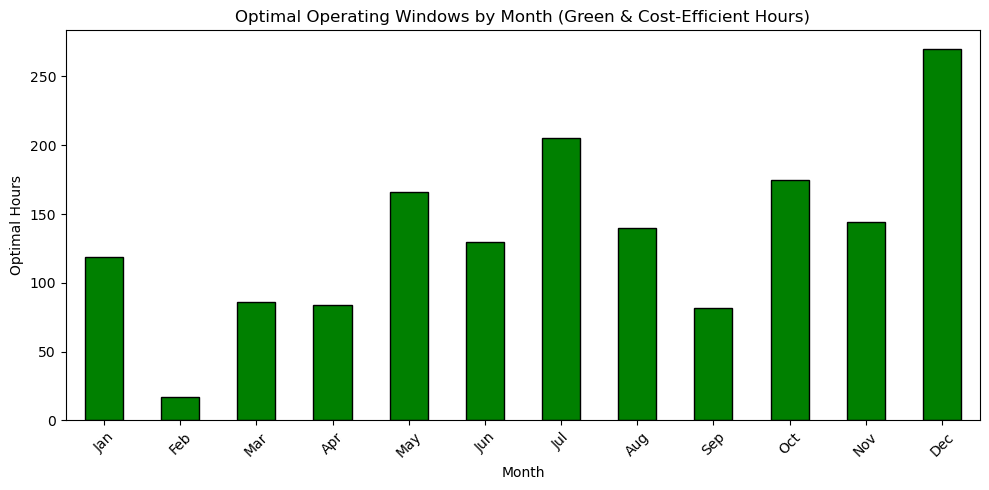

month
1     119
2      17
3      86
4      84
5     166
6     130
7     205
8     140
9      82
10    175
11    144
12    270
dtype: int64


In [55]:


# Add month column for analysis
df_merged['month'] = df_merged['timestamp'].dt.month
optimal_windows['month'] = optimal_windows['timestamp'].dt.month

# Count optimal hours per month
optimal_by_month = optimal_windows.groupby('month').size()

plt.figure(figsize=(10, 5))
optimal_by_month.plot(kind='bar', color='green', edgecolor='black')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun',
                                     'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.xlabel('Month')
plt.ylabel('Optimal Hours')
plt.title('Optimal Operating Windows by Month (Green & Cost-Efficient Hours)')
plt.tight_layout()
plt.show()
print(optimal_by_month)

## Optimal Operating Windows Analysis

Out of 8756 hours in 2023, **1618 hours (18.5%)** simultaneously met all three 
conditions: low price (≤75.90 EUR/MWh), low carbon intensity (≤203.06 gCO2/kWh), 
and high renewable percentage (≥71.69%).

**Best months:** December (270 hrs) and July (205 hrs). These months are driven by high renewable 
generation and low electricity prices.

**Worst months:** February (17 hrs) and September (82 hrs). These are the low renewable availability 
and higher market prices.

This confirms that green and cost-efficient periods strongly overlap, meaning scheduling 
dry room operation during these windows simultaneously minimizes both operational cost 
and carbon footprint.

## Optimal Operating Windows — Month vs Hour of Day

The monthly bar chart revealed which months have the most optimal hours, but does 
not show **at what time of day** these hours occur. To answer Task 4 specifically
"at which time periods is electricity both low-cost and low-carbon?", a more 
granular analysis is needed.

The following heatmap combines both dimensions simultaneously: month on the y-axis 
and hour of day on the x-axis. Each cell represents the number of hours in that 
month-hour combination that met all three conditions (low price, low carbon intensity, 
high renewable percentage). Darker green indicates more optimal hours, making it 
easy to identify the best time windows for dry room operation throughout the year.

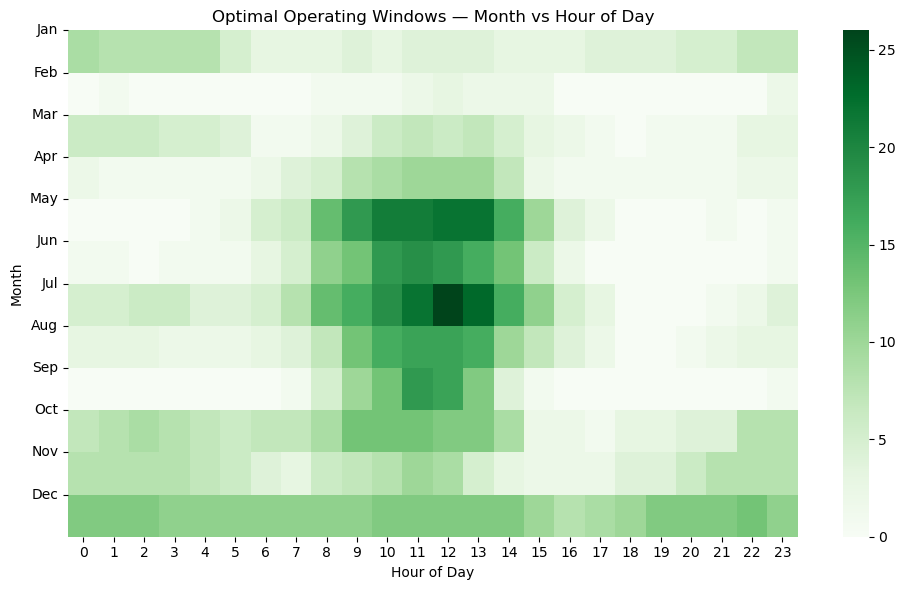

In [56]:
optimal_windows['hour'] = optimal_windows['timestamp'].dt.hour
optimal_windows['month'] = optimal_windows['timestamp'].dt.month

# Pivot table: hour vs month
pivot = optimal_windows.groupby(['month', 'hour']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap='Greens', annot=False)
plt.xlabel('Hour of Day')
plt.ylabel('Month')
plt.yticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun',
                                     'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.title('Optimal Operating Windows — Month vs Hour of Day')
plt.tight_layout()
plt.show()

## Interpretation — Optimal Operating Windows Heatmap

The heatmap reveals two key dimensions of optimal dry room operation: **time of day** 
and **time of year**.

### Time of Day
Optimal hours are strongly concentrated between **10:00 and 13:00**, coinciding with 
peak solar generation in Germany. Hours before 07:00 and after 15:00 are largely 
white, indicating that night and evening hours are rarely simultaneously low-cost 
and low-carbon. This suggests that **daytime operation, particularly late morning 
to early afternoon, is the most favorable window** from both an economic and 
environmental perspective.

### Time of Year
Two distinct seasonal patterns emerge:

- **Summer months (May–August)** show the darkest cells concentrated around midday — 
driven by high solar renewable generation pushing both carbon intensity down and 
electricity prices down simultaneously. **July between 10:00–13:00 represents the 
single most optimal operating window** in the entire year.

- **December** shows a different pattern — optimal hours are spread more evenly 
across the day rather than concentrated at midday. This is price-driven rather than 
solar-driven, likely due to low electricity demand and market conditions in early winter.Or it might be the case as it contains Christmas, New Year, and other holidays where demand and prices are naturally low.

- **February** is consistently the worst month with almost no optimal hours across 
any time of day — low renewable generation and high heating demand across Europe 
drive both prices and carbon intensity up.


## At which time periods is electricity both low-cost and low-carbon?

Electricity is simultaneously low-cost and low-carbon primarily during **daytime hours 
between 10:00 and 13:00**, driven by peak solar generation pushing both prices and 
carbon intensity down. Seasonally, this effect is strongest in **summer months 
(May–August)**, with **December** also offering low-cost hours due to reduced 
industrial demand during the holiday period.

### Practical Recommendation
For flexible scheduling of dry room operation, the following windows are recommended:
- **Primary window:** May–August, 10:00–13:00 — maximum green and cost-efficient hours
- **Secondary window:** December, spread across daytime hours — cost-efficient but 
less renewable-driven
- **Avoid:** February and all night/evening hours (after 16:00) where possible.